In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub einops

### Mamba 2

**Paper:** [arXiv:2405.21060](https://arxiv.org/abs/2405.21060) — *Transformers are SSMs: Generalized Models and Efficient Algorithms Through Structured State Space Duality* (Dao & Gu, 2024).  
**HF source:** [AntonV/mamba2-130m-hf](https://huggingface.co/AntonV/mamba2-130m-hf)

This notebook walks through a **from-scratch JAX implementation** of Mamba-2 (130M) — a structured state space model that is as expressive as linear attention while being far more efficient to compute.

---

### Paper Overview

Mamba-2's central insight is **State Space Duality (SSD)**: a class of SSMs and a class of linear attention are mathematically equivalent. This duality lets the model use a fast *parallel scan* during training (like attention) and switch to a purely *recurrent* pass at inference — no quadratic attention ever needed.

| Concept | Role |
|---|---|
| **SSD** | Bridges SSMs and linear attention; enables both parallel & recurrent modes |
| **Multi-head SSM** | H independent heads, each running an (P × N) state space |
| **Causal Conv** | Short depthwise conv (k=4) on the input before the SSM |
| **dt (∆)** | Per-head learnable timescale — discretizes the continuous SSM |
| **RMS Norm (SSD norm)** | Normalization gate inside the mixer, replacing the Mamba-1 output norm |

### Architecture at a glance (Mamba-2 130M)

```
Tokens → Embedding → h  [B, L, E=1536]
  × 24 Mamba-2 Blocks:
      RMSNorm
      in_proj  →  z [gate]  |  xBC [conv input]  |  dt [timescale]
      Causal Conv1D (k=4) on xBC
      SiLU
      split xBC  →  x [B,L,E]  ·  B [B,L,N]  ·  C [B,L,N]
      SSD  →  y        ← parallel prefill  OR  recurrent step
      D skip + RMSNorm(z) + out_proj + residual
  Final RMSNorm → unembed (tied weights)
```

Key dimensions: `E=1536`, `H=24`, `P=E//H=64`, `N=128`

### Imports

In [ ]:
import gc
import json
import os
from dataclasses import dataclass
from functools import partial
from typing import Optional

import jax
import jax.nn as jnn
import jax.numpy as jnp
import numpy as np
from einops import einsum, rearrange, repeat
from PIL import Image
from safetensors.torch import load_file


In [ ]:
HF_REPO_ID = "AntonV/mamba2-130m-hf"
LOCAL_DIR_PATH = "mamba2"

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)

print(f"Downloaded repository path: {local_dir}")

### Load Weights

Mamba-2 weights are distributed as a single `.safetensors` file. We load the raw HuggingFace checkpoint and will remap the tensors into a clean nested Python dict — one entry per transformer block.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
TOKENIZER_PATH = LOCAL_DIR_PATH

# Load the raw state dict
hf_weights = load_file(WEIGHTS_PATH)

Quick sanity check — print all weight tensor names so we can see the exact key paths before we start extracting them.

In [4]:
for key in hf_weights.keys():
    print(key)

backbone.embeddings.weight
backbone.layers.0.mixer.A_log
backbone.layers.0.mixer.D
backbone.layers.0.mixer.conv1d.bias
backbone.layers.0.mixer.conv1d.weight
backbone.layers.0.mixer.dt_bias
backbone.layers.0.mixer.in_proj.weight
backbone.layers.0.mixer.norm.weight
backbone.layers.0.mixer.out_proj.weight
backbone.layers.0.norm.weight
backbone.layers.1.mixer.A_log
backbone.layers.1.mixer.D
backbone.layers.1.mixer.conv1d.bias
backbone.layers.1.mixer.conv1d.weight
backbone.layers.1.mixer.dt_bias
backbone.layers.1.mixer.in_proj.weight
backbone.layers.1.mixer.norm.weight
backbone.layers.1.mixer.out_proj.weight
backbone.layers.1.norm.weight
backbone.layers.10.mixer.A_log
backbone.layers.10.mixer.D
backbone.layers.10.mixer.conv1d.bias
backbone.layers.10.mixer.conv1d.weight
backbone.layers.10.mixer.dt_bias
backbone.layers.10.mixer.in_proj.weight
backbone.layers.10.mixer.norm.weight
backbone.layers.10.mixer.out_proj.weight
backbone.layers.10.norm.weight
backbone.layers.11.mixer.A_log
backbone.lay

### Weight Extraction

`get_w` pops each tensor from the raw checkpoint and converts it to a JAX `bfloat16` array. We then build two structures:

- **`blocks`** — a list of 24 dicts, one per Mamba-2 layer, each holding its norm, SSM parameters, conv weights, and projection matrices.
- **`m`** — the top-level model dict: the shared token embedding, the block list, and the final norm.

In [5]:
def get_w(
    name: str,
    transpose: bool = False,
) -> jnp.ndarray:
    val = hf_weights.pop(name)
    w = jnp.array(val.detach().cpu().numpy(), dtype=jnp.bfloat16)
    return w.T if transpose else w

blocks = []
for i in range(24):
    block = {
        'norm': get_w(f"backbone.layers.{i}.norm.weight"),
        'dt_bias': get_w(f"backbone.layers.{i}.mixer.dt_bias"),
        'a_log': get_w(f"backbone.layers.{i}.mixer.A_log"),
        'd': get_w(f"backbone.layers.{i}.mixer.D"),
        'in_proj': get_w(f"backbone.layers.{i}.mixer.in_proj.weight"),
        'conv': {
            'weight': get_w(f"backbone.layers.{i}.mixer.conv1d.weight"),
            'bias': get_w(f"backbone.layers.{i}.mixer.conv1d.bias"),
        },
        'mixer_norm': get_w(f"backbone.layers.{i}.mixer.norm.weight"),
        'out_proj': get_w(f"backbone.layers.{i}.mixer.out_proj.weight"),
    }
    blocks.append(block)

m = {
    'embed': get_w('backbone.embeddings.weight'),
    'blocks': blocks,
    'norm': get_w('backbone.norm_f.weight'),
}

### Config

A small dataclass that centralises the model hyperparameters. The key dimensions we'll use throughout are:

| Symbol | Value | Meaning |
|---|---|---|
| `E` | 1536 | Hidden / embedding size (`intermediate_size`) |
| `H` | 24 | Number of SSM heads (`num_attention_heads`) |
| `N` | 128 | SSM state dimension (`space_state_dim`) |
| `P` | 64 | Head dimension = E // H |

In [6]:
@dataclass
class Config:
    vocab_size: int = 50257
    max_position_embeddings: int = 2048
    num_hidden_layers: int = 24
    hidden_size: int = 768
    intermediate_size: int = 1536
    num_attention_heads: int = 24
    space_state_dim: int = 128
    mask_token_id: int = 50256

config = Config()

### Tokenizer

Mamba-2-130M uses the **GPT-NeoX tokenizer** (same vocabulary as GPT-2, 50257 tokens). We tokenize a sample prompt to get the `token_ids` array we'll feed into the model.

In [7]:
from transformers import AutoTokenizer

input = "Can you tell me the story?"

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)
token_ids = tokenizer(input, return_tensors="np")["input_ids"]

print("Token IDs:", token_ids)

Token IDs: [[5804  368 2028  479  253 2926   32]]


### RMS Norm

A lightweight normalization that divides by the root-mean-square of the input — no mean subtraction, no bias. Cheaper than LayerNorm and works well in practice.

When `z` is provided (the gate branch), we first apply a **SiLU gate** (`x * silu(z)`) before normalizing. This is the gated-output norm used inside each Mamba-2 mixer.

In [8]:
def rms_norm(
    x: jnp.ndarray,                        # (B, L, E) or (B, E)
    weight: jnp.ndarray,                    # (E,)
    z: Optional[jnp.ndarray] = None,        # (B, L, E) or (B, E)
    eps: float = 1e-6,
):
    if z is not None:
        x = x * jnn.silu(z)
    mean_square = jnp.mean(jnp.square(x), axis=-1, keepdims=True)
    inv_rms = jax.lax.rsqrt(mean_square + eps)
    return x * inv_rms * weight


### Input Projections

A single `in_proj` linear layer maps the normalized hidden state into three distinct branches in one shot:

| Branch | Slice | Shape | Role |
|---|---|---|---|
| `z` | `[:E]` | `(B, L, E)` | Gate for the output norm |
| `xBC` | `[E : 2E+2N]` | `(B, L, E+2N)` | Input to the conv → split into x, B, C for the SSM |
| `dt` | `[-H:]` | `(B, L, H)` | Per-head timescale ∆ |

In [9]:
def split_projections(
    projections: jnp.ndarray,  # (B, L, 2E+2N+H) or (B, 2E+2N+H)
):
    z   = projections[..., :E]
    xBC = projections[..., E:2*E+N+N]
    dt  = projections[..., -H:]

    return z, xBC, dt


### Causal Convolution

Before entering the SSM, `xBC` passes through a short **depthwise causal conv** (kernel size 4). This gives the model a small receptive window of local context — something a purely recurrent SSM wouldn't have without extra cost.

The function handles **two modes**:

- **Prefill** (`conv_state=None`): pad the sequence on the left by 3 and run a standard 1D depthwise conv over all `L` positions in parallel.
- **Generation** (`conv_state` provided): concatenate the cached 3-token window with the new single token, compute the dot product, and slide the window forward.

In [10]:
def apply_causal_conv(
    xBC: jnp.ndarray,                           # (B, L, E+2N) or (B, E+2N)
    conv: dict,
    conv_state: Optional[jnp.ndarray] = None,   # (B, 3, E+2N)
):
    kernel_size = 4

    weights = conv['weight']
    bias = conv['bias']

    if conv_state is not None:
        xBC_window = jnp.concatenate([conv_state, xBC], axis=1)
        next_state = xBC_window[:, 1:, :]
        weights = weights.squeeze(1)

        out = jnp.einsum("btc, ct -> bc", xBC_window, weights)
        out = (out + bias)

        return out, next_state

    else:
        B, L, C = xBC.shape

        x_padded = jnp.pad(xBC, ((0, 0), (kernel_size - 1, 0), (0, 0)))
        weights = jnp.transpose(weights, (2, 1, 0))

        out = jax.lax.conv_general_dilated(
            x_padded,
            weights,
            window_strides=(1,),
            padding='VALID',
            dimension_numbers=('NHC', 'HIO', 'NHC'),
            feature_group_count=C
        )
        out = out + bias

        final_state = xBC[:, -(kernel_size - 1):, :]

        return out, final_state


### Segment Sum

A key primitive used inside the SSD algorithm. Given a 1-D sequence of log-decay values `A`, `segsum(A)` computes the **lower-triangular cumulative sum** — so entry `[i, j]` (i ≥ j) equals the sum `A[j] + A[j+1] + ... + A[i-1]`, and entries above the diagonal are set to `-inf`.

This gives us the log of the decay factor between any two positions, which we then exponentiate to get the full decay matrix used to weight past states.

In [11]:
def segsum(
    x: jnp.ndarray,  # (..., T)
):
    T = x.shape[-1]
    x = repeat(x, '... d -> ... d e', e=T)
    mask = jnp.tril(jnp.ones((T, T), dtype=bool), k=-1)
    x = jnp.where(mask, x, 0.)
    x_segsum = jnp.cumsum(x, axis=-2)
    mask2 = jnp.tril(jnp.ones((T, T), dtype=bool), k=0)
    x_segsum = jnp.where(mask2, x_segsum, -jnp.inf)
    return x_segsum


### SSD — Parallel Mode (Prefill)

The **State Space Dual** algorithm processes an entire prompt in parallel, similar to how attention processes a full sequence at once.

The computation splits neatly into two parts:

- **`Y_diag`** — the within-chunk contribution: for each output position, the weighted sum of inputs *within the same chunk*, using the triangular decay matrix `L`.
- **`Y_off`** — the cross-chunk contribution: the effect of states carried forward *from previous chunks*, scaled by the cumulative decay.

The two terms are summed to give the full SSM output `Y`.  
The function also returns `final_state` — the recurrent state after processing the full sequence, which is used as the starting point for autoregressive generation.

In [12]:
def ssd_forward(
    x: jnp.ndarray,                                # (B, L, H, P)
    dt: jnp.ndarray,                               # (B, L, H)
    dt_bias: jnp.ndarray,                          # (H,)
    A_log: jnp.ndarray,                            # (H,)
    B_mat: jnp.ndarray,                            # (B, L, N)
    C_mat: jnp.ndarray,                            # (B, L, N)
    initial_states: Optional[jnp.ndarray] = None,  # (B, 1, H, P, N)
):
    A_mat = -jnp.exp(A_log)
    dt = jax.nn.softplus(dt + dt_bias)

    B_mat = repeat(B_mat, 'b l n -> b l h n', h=H)
    C_mat = repeat(C_mat, 'b l n -> b l h n', h=H)

    x = x * dt[..., None]
    A_mat = A_mat * dt

    x = rearrange(x, 'b l h p -> b 1 l h p')
    A_mat = rearrange(A_mat, 'b l h -> b 1 l h')
    B_mat = rearrange(B_mat, 'b l h n -> b 1 l h n')
    C_mat = rearrange(C_mat, 'b l h n -> b 1 l h n')

    A_mat = rearrange(A_mat, 'b c l h -> b h c l')
    A_cumsum = jnp.cumsum(A_mat, axis=-1)

    L = jnp.exp(segsum(A_mat))

    Y_diag = jnp.einsum("bclhn, bcshn, bhcls, bcshp -> bclhp", C_mat, B_mat, L, x)
    decay_states = jnp.exp(A_cumsum[..., -1:] - A_cumsum)

    states = jnp.einsum("bclhn, bhcl, bclhp -> bchpn", B_mat, decay_states, x)

    if initial_states is None:
        initial_states = jnp.zeros_like(states[:, :1])

    states = jnp.concatenate([initial_states, states], axis=1)

    A_cumsum_padded = jnp.pad(A_cumsum[:, :, :, -1], ((0,0), (0,0), (1,0)), mode='constant')
    decay_chunk = jnp.exp(segsum(A_cumsum_padded))

    new_states = jnp.einsum("bhzc, bchpn -> bzhpn", decay_chunk, states)
    states, final_state = new_states[:, :-1], new_states[:, -1]

    state_decay_out = jnp.exp(A_cumsum)

    weighted_C = jnp.einsum("bclhn, bhcl -> bclhn", C_mat, state_decay_out)
    Y_off = jnp.einsum("bclhn, bchpn -> bclhp", weighted_C, states)

    Y = Y_diag + Y_off
    Y = rearrange(Y, "b c l h p -> b (c l) h p")

    return Y, final_state


### SSD — Recurrent Mode (Generation)

At inference time, we generate **one token at a time**. Instead of re-running the full parallel scan, we maintain an explicit SSM state `(B, H, P, N)` and update it with a single recurrence step:

```
new_state = A * old_state + B * x
y         = C · new_state
```

`A` and `B` are computed from the current token's `dt` (after softplus + bias). This is O(1) per step — constant cost regardless of sequence length — which is what makes Mamba-style models attractive for long-context generation.

In [13]:
def ssd_step(
    x: jnp.ndarray,      # (B, H, P)
    dt: jnp.ndarray,     # (B, H)
    dt_bias: jnp.ndarray, # (H,)
    A_log: jnp.ndarray,  # (H,)
    B_mat: jnp.ndarray,  # (B, N)
    C_mat: jnp.ndarray,  # (B, N)
    state: jnp.ndarray,  # (B, H, P, N)
):
    A_mat = -jnp.exp(A_log)
    dt = dt[0]
    dt = jax.nn.softplus(dt + dt_bias)

    dBx = jnp.einsum("bh, bn, bhp -> bhpn", dt, B_mat, x)
    A_mat = jnp.exp(dt * A_mat)

    ssm_state = state
    updated_ssm_state = ssm_state * rearrange(A_mat, "b h -> b h 1 1") + dBx

    y = jnp.einsum("bhpn, bn -> bhp", updated_ssm_state, C_mat)

    return y, updated_ssm_state


### Full Forward Pass

`mamba_forward` stacks all 24 Mamba-2 blocks and handles both modes with a single `prompt` flag:

| Flag | Conv | SSM | Use case |
|---|---|---|---|
| `prompt=True` | full sequence | `ssd_forward` (parallel) | Prefill / processing the prompt |
| `prompt=False` | sliding window via `conv_state` | `ssd_step` (recurrent) | Generating one token at a time |

`caches` is a list of 24 `(ssm_state, conv_state)` tuples — one per block. During prefill they capture the final state; during generation they are updated in-place each step.

The final logits are produced by projecting the last hidden state back through the **tied embedding matrix** (weights shared with the input embedding).

In [18]:
def mamba_forward(
    token_ids: jnp.ndarray,  # (B, L) or (B, 1)
    m: dict,
    caches: list,
    prompt: bool = False,
    output_hidden_states: bool = False,
    output_dt: bool = False,
):
    embeddings = m['embed'][token_ids]

    h = embeddings
    new_cache = []
    hidden_states = []
    dt_all = []

    for i, block in enumerate(m['blocks']):

        h_block_prev, conv_cache_prev = caches[i]

        residual = h
        x_norm = rms_norm(h, block['norm'])

        projected = x_norm @ block['in_proj'].T
        z, xBC, dt = split_projections(projected)

        if not prompt:
            xBC, conv_cache_new = apply_causal_conv(xBC, block['conv'], conv_cache_prev)
        else:
            xBC, conv_cache_new = apply_causal_conv(xBC, block['conv'])

        xBC = jax.nn.silu(xBC)

        x, B_mat, C_mat = jnp.split(xBC, [E, E + N], axis=-1)
        A_log = block['a_log']
        dt_bias = block['dt_bias']

        dt_effective = jax.nn.softplus(dt + dt_bias)  # (B, L, H) or (B, H)
        dt_all.append(dt_effective)

        if prompt:
            x = rearrange(x, 'b l (h p) -> b l h p', h=H)

            y, h_block_new = ssd_forward(x, dt, dt_bias, A_log, B_mat, C_mat)

            D = rearrange(block['d'], "h -> 1 1 h 1")
            y = y + D * x

            y = rearrange(y, "b l h p -> b l (h p)")

            y = rms_norm(y, block['mixer_norm'], z=z)

            h = (y @ block['out_proj'].T) + residual

        else:
            x = rearrange(x, 'b (h p) -> b h p', h=H)
            y, h_block_new = ssd_step(x, dt, dt_bias, A_log, B_mat, C_mat, state=h_block_prev)

            D = rearrange(block['d'], "h -> h 1")
            y = y + D * x

            y = rearrange(y, "b h p -> b (h p)")

            y = rms_norm(y, block['mixer_norm'], z=z)

            h = (y @ block['out_proj'].T) + residual

        new_cache.append((h_block_new, conv_cache_new))

        if output_hidden_states:
            hidden_states.append(h)

    h = rms_norm(h, m['norm'])
    logits = h @ m['embed'].T

    out = [logits, new_cache]

    if output_hidden_states:
        out.append(hidden_states)
    if output_dt:
        out.append(dt_all)
        
    return tuple(out)


### Initialize & Run Prefill

Before generation we set the global dimension constants (`B`, `H`, `E`, `N`, `P`) and zero-initialize the per-block caches:

- **SSM state** — `(B, H, P, N)` zeros, one per block
- **Conv state** — `(B, 3, E+2N)` zeros (the 3-token sliding window)

Then we run a **prefill pass** over the full prompt (`prompt=True`) to get the initial logits and — crucially — the populated `new_cache` that seeds autoregressive generation.

In [20]:
B = 1
H = config.num_attention_heads
E = config.intermediate_size
N = config.space_state_dim
P = E // H

caches = [
    (jnp.zeros((B, H, P, N), dtype=jnp.bfloat16), jnp.zeros((B, 3, E+N+N), dtype=jnp.bfloat16)) 
    for _ in range(config.num_hidden_layers)
]

logits, new_cache, hidden_states = mamba_forward(token_ids, m, caches, prompt=True, output_hidden_states=True)
print("Logits shape:", logits.shape)
print("New cache shapes:", [h.shape for h in new_cache[0]])
print("Hidden states shapes:", [h.shape for h in hidden_states[0]])

Logits shape: (1, 7, 50288)
New cache shapes: [(1, 24, 64, 128), (1, 3, 1792)]
Hidden states shapes: [(7, 768)]


### Autoregressive Generation

With the cache populated from prefill, `generate` runs the model one token at a time using the **recurrent path** (`prompt=False`). Each step:

1. Feeds only the **last token** into `mamba_forward`
2. Picks the **argmax** of the output logits (greedy decoding)
3. Appends the new token to the running sequence
4. Passes the **updated caches** to the next step

This is constant-cost per step — no KV cache that grows with length, just a fixed-size state.

In [21]:
def generate(
    input_ids: jnp.ndarray,  # (B, L)
    m: dict,
    caches: list,
    max_new_tokens: int = 20,
):
    current_ids = input_ids

    for _ in range(max_new_tokens):
        last_token = current_ids[:, -1:]

        logits, caches = mamba_forward(last_token, m, caches)

        next_id = jnp.argmax(logits[:, -1, :], axis=-1)

        current_ids = jnp.concatenate([current_ids, next_id[:, None]], axis=-1)

    return current_ids


In [22]:
generate_ids = generate(token_ids, m, new_cache)
print("Generated IDs:", generate_ids)
print("\nGenerated Text:", tokenizer.decode(generate_ids[0]))

Generated IDs: [[5804  368 2028  479  253 2926   32  187  187   42  717  247 2872 3416
   665  556  644 3811  275  247 1355 3874  323  253 2469 1643 1107]]

Generated Text: Can you tell me the story?

I am a young woman who has been living in a small town for the past few years


### Visualisation

### SSM State Norm Per Layer

After prefill, `new_cache` holds 24 SSM state tensors, one per block, each of shape `(B, H, P, N)`. The **Frobenius norm** of each state tells us how much information that layer is "carrying" after processing the prompt.

Layers with large norms are doing the most work — storing rich representations of the input. Layers with near-zero norms are essentially idle for this particular prompt.

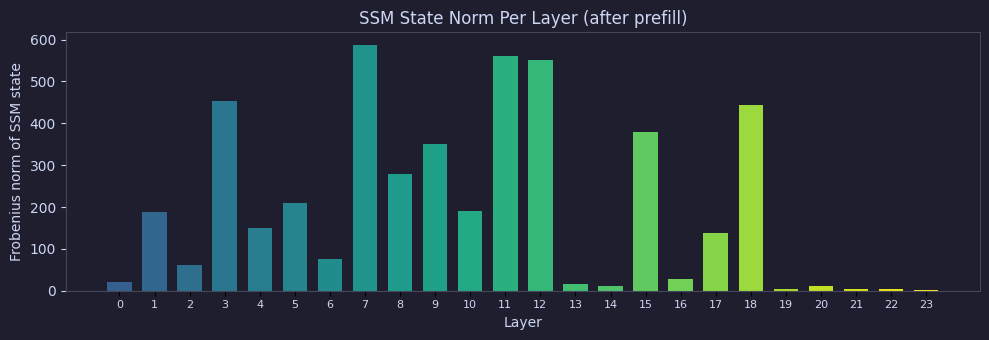

In [23]:
import matplotlib.pyplot as plt
import numpy as np

state_norms = [
    float(jnp.linalg.norm(ssm_state))
    for ssm_state, _ in new_cache
]

fig, ax = plt.subplots(figsize=(10, 3.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

colors = plt.cm.viridis(np.linspace(0.3, 1.0, len(state_norms)))
bars = ax.bar(range(len(state_norms)), state_norms, color=colors, edgecolor='none', width=0.7)

ax.set_xlabel("Layer", color='#cdd6f4')
ax.set_ylabel("Frobenius norm of SSM state", color='#cdd6f4')
ax.set_title("SSM State Norm Per Layer (after prefill)", color='#cdd6f4', fontsize=12)
ax.set_xticks(range(len(state_norms)))
ax.set_xticklabels([str(i) for i in range(len(state_norms))], color='#cdd6f4', fontsize=8)
ax.tick_params(axis='y', colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#45475a')

plt.tight_layout()
plt.show()


### Hidden State Evolution Across Layers

`hidden_states` holds the residual stream output `h` after every block, each `(B, L, E)`. The **L2 norm per token per layer** shows how the representation strengthens (or stabilises) as we go deeper — plotted as a `(num_layers, L)` heatmap.

Bright rows = layers with high-energy representations. Bright columns = tokens that the model finds most significant across layers.

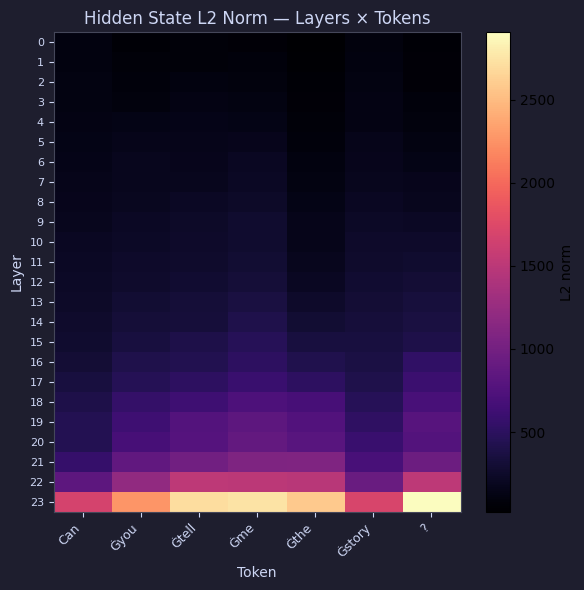

In [ ]:
# hidden_states: list of 24 tensors, each (B, L, E)
# compute L2 norm per token per layer → (num_layers, L)
tokens = tokenizer.convert_ids_to_tokens(token_ids[0].tolist())

norms = np.array([
    np.linalg.norm(np.array(h[0], dtype=np.float32), axis=-1)  # (L,)
    for h in hidden_states
])  # (24, L)

fig, ax = plt.subplots(figsize=(max(6, len(tokens) * 0.6), 6))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

im = ax.imshow(norms, aspect='auto', cmap='magma', origin='upper')
plt.colorbar(im, ax=ax, label='L2 norm')

ax.set_xlabel("Token", color='#cdd6f4')
ax.set_ylabel("Layer", color='#cdd6f4')
ax.set_title("Hidden State L2 Norm — Layers x Tokens", color='#cdd6f4', fontsize=12)
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha='right', color='#cdd6f4', fontsize=9)
ax.set_yticks(range(len(hidden_states)))
ax.set_yticklabels([str(i) for i in range(len(hidden_states))], color='#cdd6f4', fontsize=8)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#45475a')

plt.tight_layout()
plt.show()


### dt Timescale Heatmap

`dt` (after softplus + bias) is the **per-head timescale** — it controls the rate of state decay at each position. A large `dt` means the head changes state slowly (long memory); a small `dt` means fast forgetting (short memory).

We re-run the prefill with `output_dt=True` to collect `dt_effective` from every block, then plot the **mean dt per head per layer** as a `(24, H)` heatmap — revealing which heads and layers are operating on long vs short timescales.

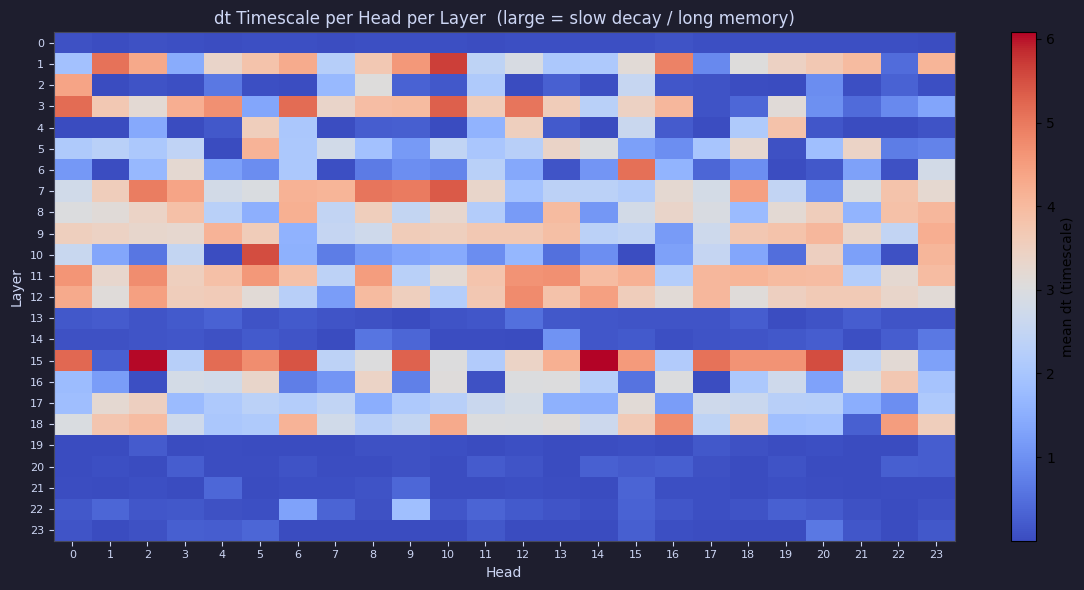

Global dt  min: 0.0004   max: 6.0781   mean: 1.7311


In [26]:
# Re-run prefill collecting dt — caches is still the original zeros (JAX is functional)
*_, dt_all = mamba_forward(token_ids, m, caches, prompt=True, output_hidden_states=False, output_dt=True)

# dt_all: list of 24 tensors, each (B, L, H) in prompt mode
# mean over batch + sequence → (24, H)
dt_mean = np.array([
    np.array(dt[0], dtype=np.float32).mean(axis=0)  # (H,)
    for dt in dt_all
])  # (24, H)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

im = ax.imshow(dt_mean, aspect='auto', cmap='coolwarm', origin='upper')
plt.colorbar(im, ax=ax, label='mean dt (timescale)')

ax.set_xlabel("Head", color='#cdd6f4')
ax.set_ylabel("Layer", color='#cdd6f4')
ax.set_title("dt Timescale per Head per Layer  (large = slow decay / long memory)", color='#cdd6f4', fontsize=12)
ax.set_xticks(range(H))
ax.set_xticklabels([str(i) for i in range(H)], color='#cdd6f4', fontsize=8)
ax.set_yticks(range(len(dt_all)))
ax.set_yticklabels([str(i) for i in range(len(dt_all))], color='#cdd6f4', fontsize=8)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#45475a')

plt.tight_layout()
plt.show()

print(f"Global dt  min: {dt_mean.min():.4f}   max: {dt_mean.max():.4f}   mean: {dt_mean.mean():.4f}")
